In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
    cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler, StandardScaler

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_colwidth", 120)

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/yeast/yeast.data"
columns = [
    "sequence_name", "mcg", "gvh", "alm", "mit", "erl", "pox", "vac", "nuc", "localization_site"
]

df = pd.read_csv(url, sep=r"\s+", names=columns)
df.head()

,sequence_name,mcg,gvh,alm,mit,erl,pox,vac,nuc,localization_site
0,ADT1_YEAST,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,ADT2_YEAST,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,ADT3_YEAST,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,AAR2_YEAST,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,AATM_YEAST,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


In [2]:
print(f"Liczba próbek: {len(df)}")
print(f"Liczba cech numerycznych: {df.shape[1] - 2}")

y_raw = df["localization_site"]
print("\nRozkład klas (przed usunięciem rzadkiej klasy):")
display(y_raw.value_counts())

Liczba próbek: 1484
Liczba cech numerycznych: 8

Rozkład klas (przed usunięciem rzadkiej klasy):


localization_site
CYT    463
NUC    429
MIT    244
ME3    163
ME2     51
ME1     44
EXC     35
VAC     30
POX     20
ERL      5
Name: count, dtype: int64

In [3]:
df = df[df["localization_site"] != "ERL"].reset_index(drop=True)

X = df.drop(columns=["sequence_name", "localization_site"])
y = df["localization_site"]

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

print("Rozkład klas (po usunięciu ERL):")
display(y.value_counts())
print("\nKlasy po kodowaniu:")
print(dict(enumerate(label_encoder.classes_)))

Rozkład klas (po usunięciu ERL):


localization_site
CYT    463
NUC    429
MIT    244
ME3    163
ME2     51
ME1     44
EXC     35
VAC     30
POX     20
Name: count, dtype: int64


Klasy po kodowaniu:
{0: 'CYT', 1: 'EXC', 2: 'ME1', 3: 'ME2', 4: 'ME3', 5: 'MIT', 6: 'NUC', 7: 'POX', 8: 'VAC'}


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42,
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (1183, 8) | X_test: (296, 8)


Uzasadnienie zakresów Gridsearch:
- n_neighbors: 1..41 (nieparzyste) - szeroki zakres, nieparzyste wartości ograniczają remisy.
- weights: uniform, distance - standardowe wybory
- metric: euclidean, manhattan, chebyshev, minkowski (dla p=1,2,3) - najczęściej używane

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mcc_scorer = make_scorer(matthews_corrcoef)

base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_jobs=-1)),
])

param_grid = [
    {
        "knn__n_neighbors": list(range(1, 42, 2)),
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan", "chebyshev"],
    },
    {
        "knn__n_neighbors": list(range(1, 42, 2)),
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["minkowski"],
        "knn__p": [1, 2, 3],
    },
]

precision_weighted_scorer = make_scorer(precision_score, average="weighted", zero_division=0)
recall_weighted_scorer = make_scorer(recall_score, average="weighted", zero_division=0)

scoring = {
    "accuracy": "accuracy",
    "precision_weighted": precision_weighted_scorer,
    "recall_weighted": recall_weighted_scorer,
    "mcc": mcc_scorer,
}

grid = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="mcc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

grid.fit(X_train, y_train)

print("Najlepsze parametry:")
print(grid.best_params_)

Najlepsze parametry:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'knn__weights': 'distance'}


In [6]:
cv_results = pd.DataFrame(grid.cv_results_).sort_values("rank_test_mcc").reset_index(drop=True)

top_cols = [
    "params",
    "mean_test_accuracy",
    "mean_test_precision_weighted",
    "mean_test_recall_weighted",
    "mean_test_mcc",
]

top_results = cv_results[top_cols].head(10).copy()
for c in top_cols[1:]:
    top_results[c] = top_results[c].round(4)

display(top_results)

,params,mean_test_accuracy,mean_test_precision_weighted,mean_test_recall_weighted,mean_test_mcc
0,"{'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'knn__weights': 'distance'}",0.6069,0.6061,0.6069,0.4885
1,"{'knn__metric': 'minkowski', 'knn__n_neighbors': 21, 'knn__p': 2, 'knn__weights': 'distance'}",0.6069,0.6061,0.6069,0.4885
2,"{'knn__metric': 'minkowski', 'knn__n_neighbors': 19, 'knn__p': 2, 'knn__weights': 'distance'}",0.6061,0.6044,0.6061,0.4868
3,"{'knn__metric': 'euclidean', 'knn__n_neighbors': 19, 'knn__weights': 'distance'}",0.6061,0.6044,0.6061,0.4868
4,"{'knn__metric': 'euclidean', 'knn__n_neighbors': 25, 'knn__weights': 'distance'}",0.6035,0.6029,0.6035,0.4847
5,"{'knn__metric': 'minkowski', 'knn__n_neighbors': 25, 'knn__p': 2, 'knn__weights': 'distance'}",0.6035,0.6029,0.6035,0.4847
6,"{'knn__metric': 'minkowski', 'knn__n_neighbors': 19, 'knn__p': 1, 'knn__weights': 'distance'}",0.6035,0.6054,0.6035,0.4847
7,"{'knn__metric': 'manhattan', 'knn__n_neighbors': 19, 'knn__weights': 'distance'}",0.6035,0.6054,0.6035,0.4847
8,"{'knn__metric': 'euclidean', 'knn__n_neighbors': 23, 'knn__weights': 'distance'}",0.6027,0.6044,0.6027,0.4832
9,"{'knn__metric': 'minkowski', 'knn__n_neighbors': 23, 'knn__p': 2, 'knn__weights': 'distance'}",0.6027,0.6044,0.6027,0.4832


In [7]:
best_model = grid.best_estimator_
y_pred_test = best_model.predict(X_test)

test_scores = pd.DataFrame([
    {
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision_weighted": precision_score(y_test, y_pred_test, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred_test, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred_test),
    }
]).round(4)

print("Najlepszy wynik CV (MCC):", round(grid.best_score_, 4))
display(test_scores)

Najlepszy wynik CV (MCC): 0.4885


,accuracy,precision_weighted,recall_weighted,mcc
0,0.6318,0.6313,0.6318,0.5202


Wszystkie miary (accuracy, precision_weighted, recall_weighted, MCC) wskazują ten sam trend: najlepszy model osiąga umiarkowaną jakość. Najlepsza konfiguracja (k=21, distance, euclidean) t0 kompromis między bias/variance. precision_weighted i recall_weighted są właściwe dla niezbalansowanego zbioru, bo każda klasa wpływa na wynik proporcjonalnie do liczności. MCC ~0.5 oznacza wyraźnie lepszy wynik niż losowy, ale daleki od bardzo dobrej separacji klas.

In [8]:
best_knn_params = {k.replace("knn__", ""): v for k, v in grid.best_params_.items()}

feature_rows = []
for n_features in [2, 3, 4, 5, "auto"]:
    estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(**best_knn_params, n_jobs=-1)),
    ])

    sfs = SequentialFeatureSelector(
        estimator=estimator,
        n_features_to_select=n_features,
        direction="forward",
        scoring=mcc_scorer,
        cv=cv,
        n_jobs=-1,
    )
    sfs.fit(X_train, y_train)

    selected_features = X_train.columns[sfs.get_support()].tolist()

    model = clone(estimator)
    model.fit(X_train[selected_features], y_train)
    y_pred = model.predict(X_test[selected_features])

    feature_rows.append(
        {
            "n_features_to_select": n_features,
            "selected_count": len(selected_features),
            "selected_features": selected_features,
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "test_recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "test_mcc": matthews_corrcoef(y_test, y_pred),
        }
    )

feature_results = pd.DataFrame(feature_rows)
for c in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_mcc"]:
    feature_results[c] = feature_results[c].round(4)

display(feature_results)

,n_features_to_select,selected_count,selected_features,test_accuracy,test_precision_weighted,test_recall_weighted,test_mcc
0,2,2,"[alm, nuc]",0.4459,0.4153,0.4459,0.2660
1,3,3,"[alm, mit, nuc]",0.4662,0.4601,0.4662,0.2985
2,4,4,"[mcg, alm, mit, nuc]",0.5676,0.5591,0.5676,0.4354
3,5,5,"[mcg, gvh, alm, mit, nuc]",0.6115,0.6076,0.6115,0.4937
4,auto,4,"[mcg, alm, mit, nuc]",0.5676,0.5591,0.5676,0.4354


auto wybiera 4 cechy

In [9]:
scalers = {
    "no_scaling": "passthrough",
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

scale_rows = []
for scaler_name, scaler in scalers.items():
    pipe = Pipeline([
        ("scaler", scaler),
        ("knn", KNeighborsClassifier(**best_knn_params, n_jobs=-1)),
    ])

    cv_mcc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=mcc_scorer, n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    scale_rows.append(
        {
            "scaler": scaler_name,
            "cv_mcc_mean": np.mean(cv_mcc),
            "cv_mcc_std": np.std(cv_mcc),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "test_recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "test_mcc": matthews_corrcoef(y_test, y_pred),
        }
    )

scale_results = pd.DataFrame(scale_rows).sort_values("test_mcc", ascending=False).reset_index(drop=True)
for c in ["cv_mcc_mean", "cv_mcc_std", "test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_mcc"]:
    scale_results[c] = scale_results[c].round(4)

display(scale_results)

,scaler,cv_mcc_mean,cv_mcc_std,test_accuracy,test_precision_weighted,test_recall_weighted,test_mcc
0,standard,0.4885,0.0400,0.6318,0.6313,0.6318,0.5202
1,robust,0.4580,0.0331,0.6182,0.6116,0.6182,0.4996
2,no_scaling,0.4774,0.0382,0.6149,0.6130,0.6149,0.4978
3,minmax,0.4822,0.0372,0.5912,0.5949,0.5912,0.4674


- Im więcej sensownych cech (od 2 do 5), tym wynik rośnie; 2 cechy to za mało, co widać po dużym spadku MCC.
- auto (4 cechy) daje wynik pośredni — lepszy niż 2/3 cechy, gorszy niż 5.
- W skalowaniu najlepszy był StandardScaler; RobustScaler i brak skalowania były nieco gorsze, a MinMaxScaler najsłabszy.

Najlepsza para cech dla n=2: ['alm', 'nuc']


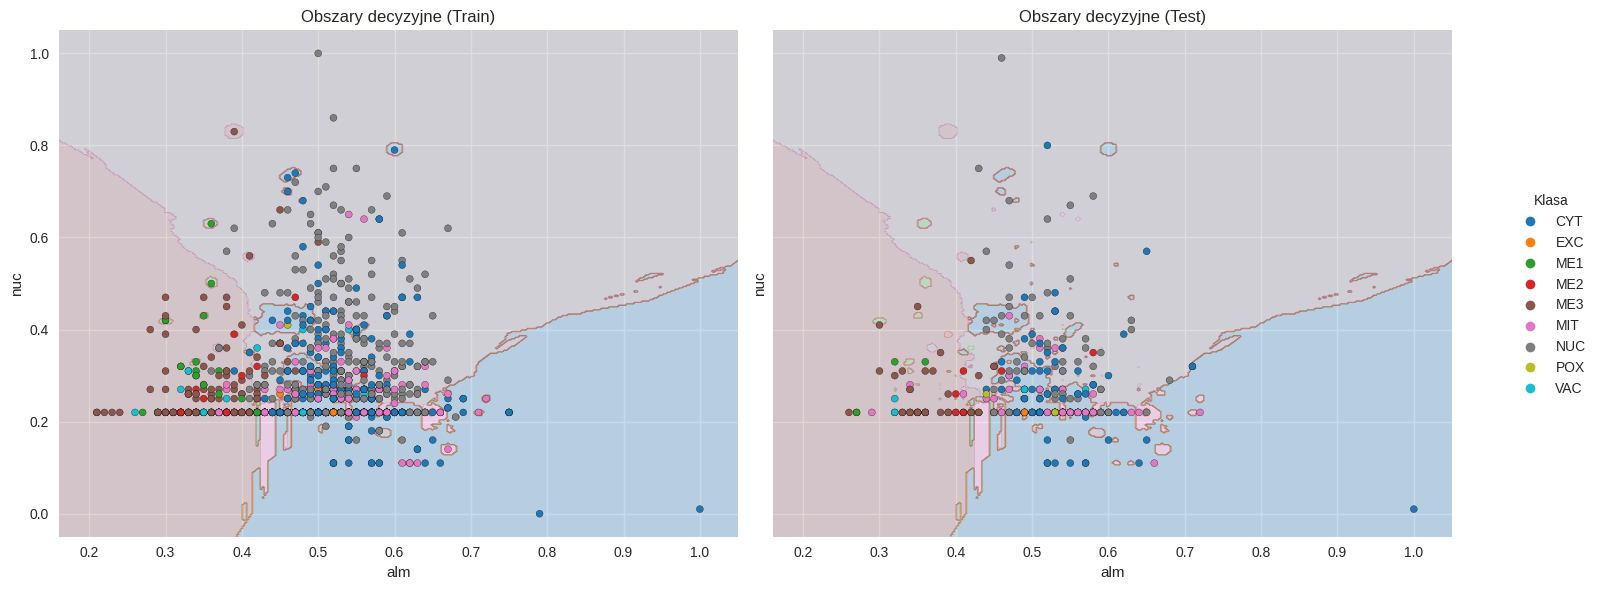

In [10]:
best_pair = feature_results.loc[
    feature_results["n_features_to_select"].astype(str) == "2", "selected_features"
].iloc[0]

print("Najlepsza para cech dla n=2:", best_pair)

X_train_2 = X_train[best_pair].copy()
X_test_2 = X_test[best_pair].copy()

model_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(**best_knn_params, n_jobs=-1)),
])
model_2d.fit(X_train_2, y_train)

x_min = min(X_train_2.iloc[:, 0].min(), X_test_2.iloc[:, 0].min()) - 0.05
x_max = max(X_train_2.iloc[:, 0].max(), X_test_2.iloc[:, 0].max()) + 0.05
y_min = min(X_train_2.iloc[:, 1].min(), X_test_2.iloc[:, 1].min()) - 0.05
y_max = max(X_train_2.iloc[:, 1].max(), X_test_2.iloc[:, 1].max()) + 0.05

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350), np.linspace(y_min, y_max, 350))
grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=best_pair)
zz = model_2d.predict(grid_points).reshape(xx.shape)

classes = np.unique(y_train)
n_classes = len(classes)
cmap = plt.get_cmap("tab10", n_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
for ax, X_split, y_split, title in [
    (axes[0], X_train_2, y_train, "Train"),
    (axes[1], X_test_2, y_test, "Test"),
]:
    ax.contourf(
        xx,
        yy,
        zz,
        levels=np.arange(-0.5, n_classes + 0.5, 1),
        cmap=cmap,
        alpha=0.25,
    )
    ax.scatter(
        X_split.iloc[:, 0],
        X_split.iloc[:, 1],
        c=y_split,
        cmap=cmap,
        s=25,
        edgecolor="k",
        linewidth=0.2,
    )
    ax.set_title(f"Obszary decyzyjne ({title})")
    ax.set_xlabel(best_pair[0])
    ax.set_ylabel(best_pair[1])

handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=label_encoder.inverse_transform([cls])[0],
        markerfacecolor=cmap(cls),
        markeredgecolor="k",
        markersize=7,
    )
    for cls in classes
]
fig.legend(handles=handles, loc="center right", title="Klasa")
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

- Granice decyzyjne są mocno poszarpane, a klasy wyraźnie się nakładają.
- Dla 2 cech separacja jest ograniczona, co zgadza się z niskim MCC dla n_features_to_select=2.
- Widać duży poziom niepewności na granicach regionów, szczególnie dla klas mniejszościowych.

Wniosek: kNN jest akceptowalnym baselinem, ale nie jest idealnym klasyfikatorem dla tego problemu.
- Plusy: działa bez skomplikowanego treningu i daje sensowne wyniki (MCC ~ 0.5 dla najlepszego wariantu).
- Minusy: mocna zależność od skali, metryki i liczby cech; trudności przy klasach mniejszościowych i nakładających się regionach.